*   Notebook Author - Chathila Wijesinghe

In [ ]:
#Importing pandas library
import pandas as pd

#Importing numpy library
import numpy as np

#Importing plotly
import plotly.express as px

import matplotlib.pyplot as plt

# To transform your features into new values
from sklearn import preprocessing

# To transform your features into new values
from sklearn.preprocessing import StandardScaler

# Import GridSearchCV for hyperparameter tuning using cross-validation
from sklearn.model_selection import GridSearchCV

# Import train_test_split function
from sklearn.model_selection import train_test_split

# To create and plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# To produce the classification metrics report
from sklearn.metrics import classification_report

# To create, calculate and plot the RoC curve
from sklearn.metrics import RocCurveDisplay

# Import GaussianNB model for probabilistic classification
from sklearn.naive_bayes import GaussianNB
# Import Logistic Regression model for binary classification
from sklearn.linear_model import LogisticRegression
# Import K-Nearest Neighbors classifier for distance-based classification
from sklearn.neighbors import KNeighborsClassifier

#Loading data into a DataFrame
dataset=pd.read_csv('/content/classification_loan_data.csv')

Tutorial 3

In [ ]:
# All training data except the target column
X = dataset.drop(["loan_approval_status"], axis = 1)
# select target variable to model, loan_approval_status
y = dataset['loan_approval_status']

print("features used for the model: ")
features = X.columns
print("[")
for f in features:
    print(f"  '{f}',")
print("]")

print(f"\nfeature shape (X): {X.shape}")
print(f"target shape (Y): {y.shape}")

features used for the model: 
[
  'age',
  'income',
  'employment_length',
  'loan_amount',
  'loan_interest_rate',
  'loan_income_ratio',
  'credit_history_length',
  'home_ownership_MORTGAGE',
  'home_ownership_OWN',
  'home_ownership_RENT',
]

feature shape (X): (58467, 10)
target shape (Y): (58467,)


Tutorial 4

In [ ]:
# Split dataset into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

# Initialize scaler to standardize features
scaler = StandardScaler()

# Scaled train/test dataset
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {y_train.shape}")
print(f"Y_test shape: {y_test.shape}")

print(f"\nX_train scaled shape: {X_train_scaled.shape}")
print(f"X_test scaled  shape: {X_test_scaled.shape}")

X_train shape: (46773, 10)
X_test shape: (11694, 10)
Y_train shape: (46773,)
Y_test shape: (11694,)

X_train scaled shape: (46773, 10)
X_test scaled  shape: (11694, 10)


In [ ]:
# Train-test ratios

print("\nOverall ratio:", y.value_counts(normalize=True), "\n")

print("Training ratio:", y_train.value_counts(normalize=True), "\n")

print("Test ratio:", y_test.value_counts(normalize=True))


Overall ratio: loan_approval_status
0    0.857509
1    0.142491
Name: proportion, dtype: float64 

Training ratio: loan_approval_status
0    0.857503
1    0.142497
Name: proportion, dtype: float64 

Test ratio: loan_approval_status
0    0.857534
1    0.142466
Name: proportion, dtype: float64


Tutorial 4

========== Classification Report: GaussianNB ==========

              precision    recall  f1-score   support

           0       0.95      0.75      0.84     10028
           1       0.34      0.79      0.48      1666

    accuracy                           0.76     11694
   macro avg       0.65      0.77      0.66     11694
weighted avg       0.87      0.76      0.79     11694





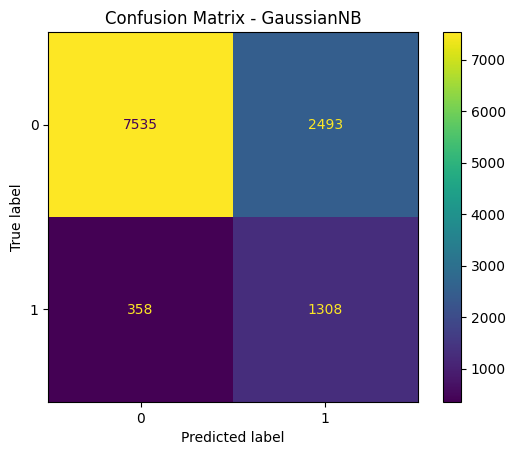

<Figure size 640x480 with 0 Axes>

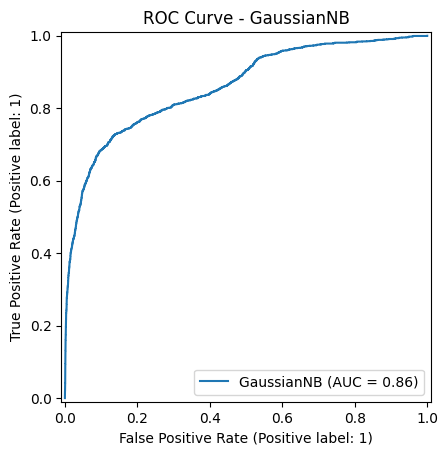

In [ ]:
# GaussianNB Model

# instantiate the GNB model (using the default parameters)
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)
y_pred_gnb=gnb.predict(X_test_scaled)

print("========== Classification Report: GaussianNB ==========\n")
print(classification_report(y_test, y_pred_gnb))

# GNB Confusion matrix
print("\n")
cm_gnb = confusion_matrix(y_test, y_pred_gnb, labels = gnb.classes_)
gnb_cm = ConfusionMatrixDisplay(cm_gnb, display_labels = gnb.classes_)
gnb_cm.plot()
plt.title("Confusion Matrix - GaussianNB")
plt.show()

# GNB Roc curve
plt.figure()
gnb_roc = RocCurveDisplay.from_estimator(gnb, X_test_scaled, y_test)
plt.title("ROC Curve - GaussianNB")
plt.show()

Tutorial 3

============= Classification Report: LR ==============

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     10028
           1       0.39      0.83      0.53      1666

    accuracy                           0.79     11694
   macro avg       0.68      0.81      0.70     11694
weighted avg       0.88      0.79      0.82     11694





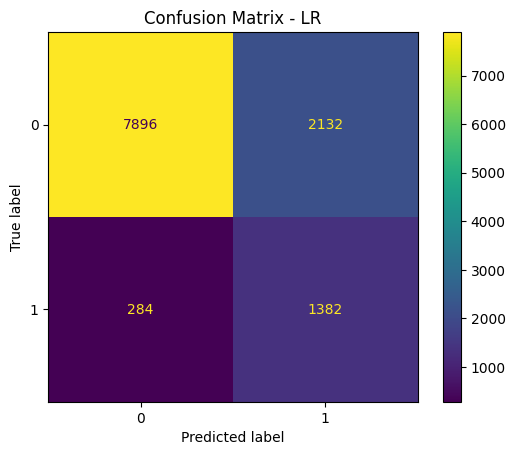

<Figure size 640x480 with 0 Axes>

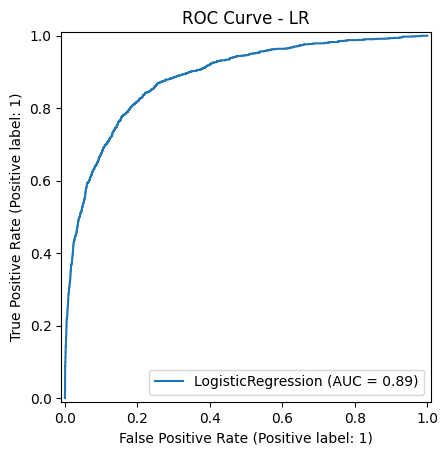

In [ ]:
# Logistic Regression Model

# instantiate the LR model (using the default parameters)
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr=lr.predict(X_test_scaled)

print("============= Classification Report: LR ==============\n")
print(classification_report(y_test, y_pred_lr))

# LR confusion matrix
print("\n")
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=lr.classes_)
lr_cm = ConfusionMatrixDisplay(cm_lr,display_labels=lr.classes_)
lr_cm.plot()
plt.title("Confusion Matrix - LR")
plt.show()

# LR roc curve
plt.figure()
lr_roc = RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.title("ROC Curve - LR")
plt.show()

Tutorial 4

default n_neighbors value: 5

============= Classification Report: KNN =============

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10028
           1       0.78      0.57      0.66      1666

    accuracy                           0.92     11694
   macro avg       0.86      0.77      0.81     11694
weighted avg       0.91      0.92      0.91     11694





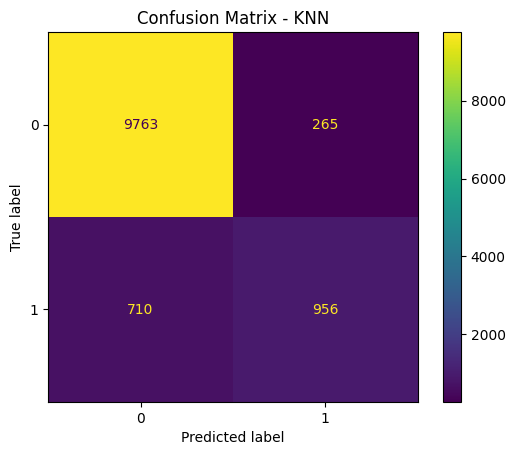

<Figure size 640x480 with 0 Axes>

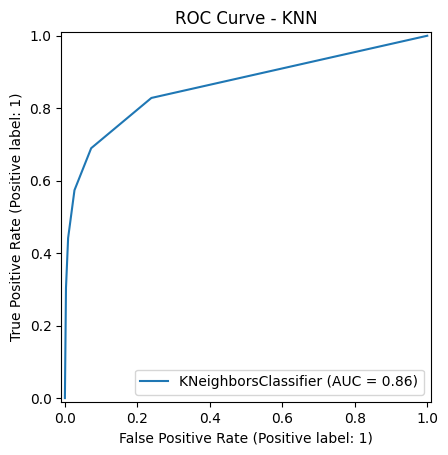

In [ ]:
# KNN model

# instantiate the KNN model (using the default parameters)
knn = KNeighborsClassifier()
print(f"default n_neighbors value: {knn.n_neighbors}\n")
# Fit the classifier to the data
knn.fit(X_train_scaled, y_train)
#Perform predictions on the test data
y_pred_knn=knn.predict(X_test_scaled)

print("============= Classification Report: KNN =============\n")
print(classification_report(y_test, y_pred_knn))

# KNN confusion matrix
print("\n")
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=knn.classes_)
knn_cm = ConfusionMatrixDisplay(cm_knn,display_labels=knn.classes_)
knn_cm.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

# knn roc curve
plt.figure()
knn_roc = RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test)
plt.title("ROC Curve - KNN")
plt.show()

========== Classification Report: GaussianNB ==========

              precision    recall  f1-score   support

           0       0.95      0.75      0.84     10028
           1       0.34      0.79      0.48      1666

    accuracy                           0.76     11694
   macro avg       0.65      0.77      0.66     11694
weighted avg       0.87      0.76      0.79     11694

============= Classification Report: LR ==============

              precision    recall  f1-score   support

           0       0.97      0.79      0.87     10028
           1       0.39      0.83      0.53      1666

    accuracy                           0.79     11694
   macro avg       0.68      0.81      0.70     11694
weighted avg       0.88      0.79      0.82     11694

============= Classification Report: KNN =============

              precision    recall  f1-score   support

           0       0.93      0.97      0.95     10028
           1       0.78      0.57      0.66      1666

    accuracy 

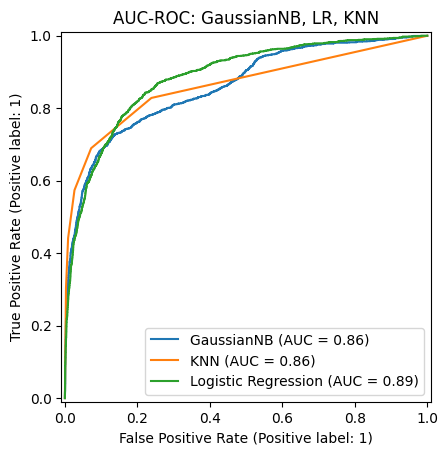

In [ ]:
# for easier comparison

print("========== Classification Report: GaussianNB ==========\n")
print(classification_report(y_test, y_pred_gnb))

print("============= Classification Report: LR ==============\n")
print(classification_report(y_test, y_pred_lr))

print("============= Classification Report: KNN =============\n")
print(classification_report(y_test, y_pred_knn))


print("\n\n AUC-Roc comparison:\n")
fig, ax = plt.subplots()

# GaussianNB
RocCurveDisplay.from_estimator(gnb, X_test_scaled, y_test, ax=ax, name="GaussianNB")

# KNN
RocCurveDisplay.from_estimator(knn, X_test_scaled, y_test, ax=ax, name="KNN")

# Logistic Regression
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test, ax=ax, name="Logistic Regression")

plt.title("AUC-ROC: GaussianNB, LR, KNN")
plt.show()

**Best fit model = KNN Classifier !**

Tutorial 4

In [ ]:
# Hypterparameter tuning and retraining the KNN model

#create a dictionary of all values we want to test for n_neighbors and distances
param_grid = {'n_neighbors': np.arange(1, 25), 'metric': ['euclidean', 'manhattan']}

#use gridsearch to test all values for n_neighbors
knn_gscv = GridSearchCV(knn, param_grid, cv=5, scoring = 'roc_auc')

#fit model to data
knn_gscv.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])},
             scoring='roc_auc')

Tutorial 4

In [ ]:
# Check top performing n_neighbors’ value
knn_gscv.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(24)}

Tutorial 4

====== Classification Report: KNN GridSearchCV ======

              precision    recall  f1-score   support

           0       0.92      0.99      0.96     10028
           1       0.90      0.50      0.65      1666

    accuracy                           0.92     11694
   macro avg       0.91      0.75      0.80     11694
weighted avg       0.92      0.92      0.91     11694





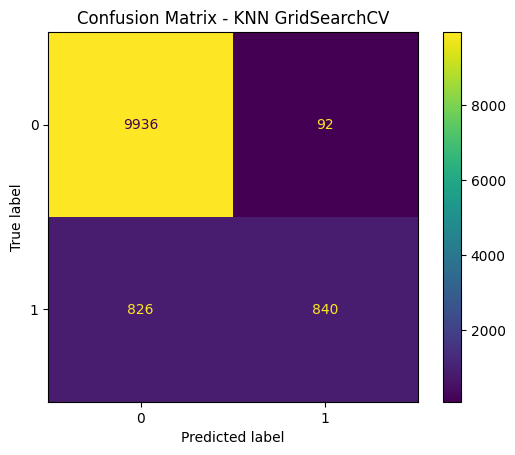

<Figure size 640x480 with 0 Axes>

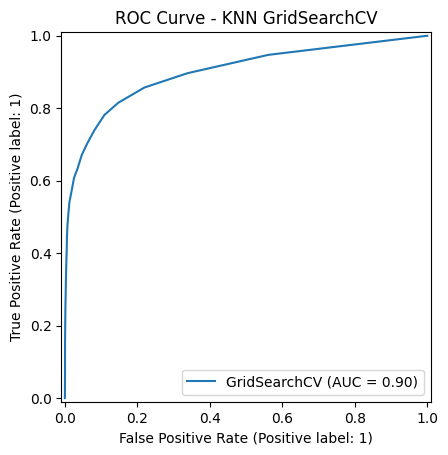

In [ ]:
# Perform testing on test dataset
y_pred_gscv = knn_gscv.predict(X_test_scaled)

# Display the classification report
print("====== Classification Report: KNN GridSearchCV ======\n")
print(classification_report(y_test, y_pred_gscv))

# Construct a confusion matrix
print("\n")
cm_knn_gscv = confusion_matrix(y_test, y_pred_gscv, labels=knn_gscv.classes_)
disp_knn_gscv_cm = ConfusionMatrixDisplay(cm_knn_gscv,display_labels=knn_gscv.classes_)
disp_knn_gscv_cm.plot()
plt.title("Confusion Matrix - KNN GridSearchCV")
plt.show()

# knn roc curve
plt.figure()
knn_gscv_roc = RocCurveDisplay.from_estimator(knn_gscv, X_test_scaled, y_test)
plt.title("ROC Curve - KNN GridSearchCV")
plt.show()